# Part 1: Exploratory Data Analysis (EDA)
## Netflix Prize Dataset - Dense Subset

This notebook performs a detailed exploratory data analysis on the preprocessed dense subset of the Netflix Prize Dataset. 
The analysis covers:
- Basic dataset size and statistics
- Rating distributions
- User activity patterns
- Content popularity trends
- Data sparsity characteristics
- Key insights and technical implications for recommendation modeling

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for visualizations
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13

print("Libraries imported successfully.")

Libraries imported successfully.


### 1. Load the Data

In [2]:
ratings_path = os.path.join("..", "data", "processed", "ratings_subset.csv")
movies_path = os.path.join("..", "data", "processed", "movies_subset.csv")

df_ratings = pd.read_csv(ratings_path)
df_movies = pd.read_csv(movies_path)

print(f"Ratings shape: {df_ratings.shape}")
print(f"Movies shape: {df_movies.shape}")

Ratings shape: (5702695, 4)
Movies shape: (1287, 3)


### 2. Dataset Overview & Data Sparsity

In [3]:
n_ratings = len(df_ratings)
n_users = df_ratings["user_id"].nunique()
n_movies = df_ratings["movie_id"].nunique()

# Sparsity calculation
max_possible_ratings = n_users * n_movies
sparsity = (1 - (n_ratings / max_possible_ratings)) * 100
density = (n_ratings / max_possible_ratings) * 100

print(f"Total Ratings: {n_ratings:,}")
print(f"Unique Users: {n_users:,}")
print(f"Unique Movies: {n_movies:,}")
print(f"Matrix Density: {density:.4f}%")
print(f"Matrix Sparsity: {sparsity:.4f}%")

Total Ratings: 5,702,695
Unique Users: 21,045
Unique Movies: 1,287
Matrix Density: 21.0549%
Matrix Sparsity: 78.9451%


### 3. Rating Distribution

In [4]:
rating_counts = df_ratings["rating"].value_counts().sort_index()
rating_pct = df_ratings["rating"].value_counts(normalize=True).sort_index() * 100

for r, count, pct in zip(rating_counts.index, rating_counts.values, rating_pct.values):
    print(f"Rating {r}: {count:10,} reviews ({pct:.2f}%)")

mean_rating = df_ratings["rating"].mean()
median_rating = df_ratings["rating"].median()
print(f"\nMean Rating: {mean_rating:.3f}")
print(f"Median Rating: {median_rating:.1f}")

Rating 1:    278,177 reviews (4.88%)
Rating 2:    668,426 reviews (11.72%)
Rating 3:  1,864,019 reviews (32.69%)
Rating 4:  1,836,963 reviews (32.21%)
Rating 5:  1,055,110 reviews (18.50%)



Mean Rating: 3.477
Median Rating: 4.0


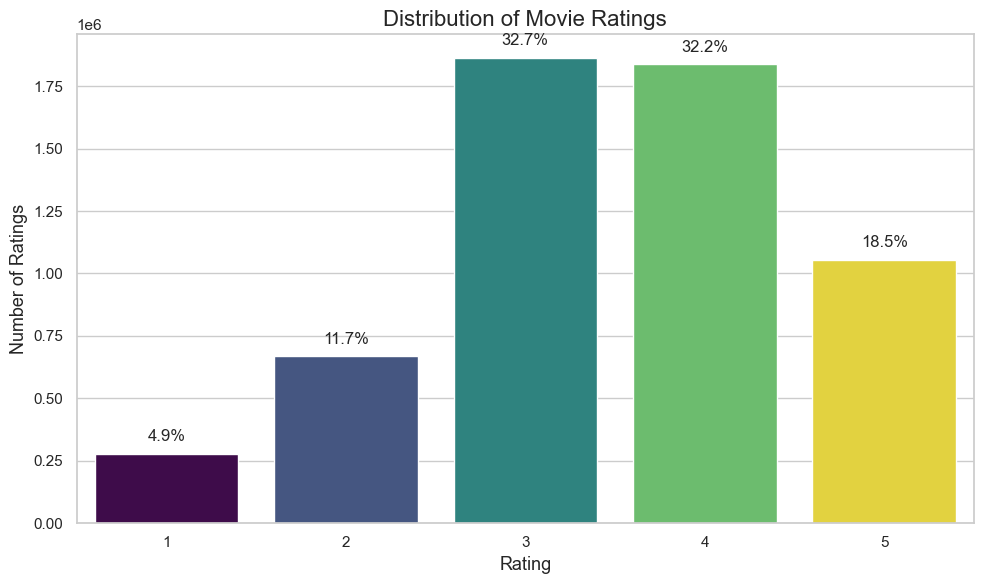

In [5]:
# Plotting Rating Distribution
ax = sns.barplot(x=rating_counts.index, y=rating_counts.values, hue=rating_counts.index, palette="viridis", legend=False)
plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")

# Add percent labels
for i, p in enumerate(ax.patches):
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 50000, f'{rating_pct.iloc[i]:.1f}%', ha="center")

plt.tight_layout()
plt.savefig("rating_distribution.png", dpi=300)
plt.show()

### 4. User Activity Patterns

In [6]:
user_ratings_count = df_ratings.groupby("user_id")["rating"].count()
print("User Rating Activity summary statistics:")
print(user_ratings_count.describe())

User Rating Activity summary statistics:
count    21045.000000
mean       270.976241
std         87.759802
min         87.000000
25%        212.000000
50%        245.000000
75%        303.000000
max       1281.000000
Name: rating, dtype: float64


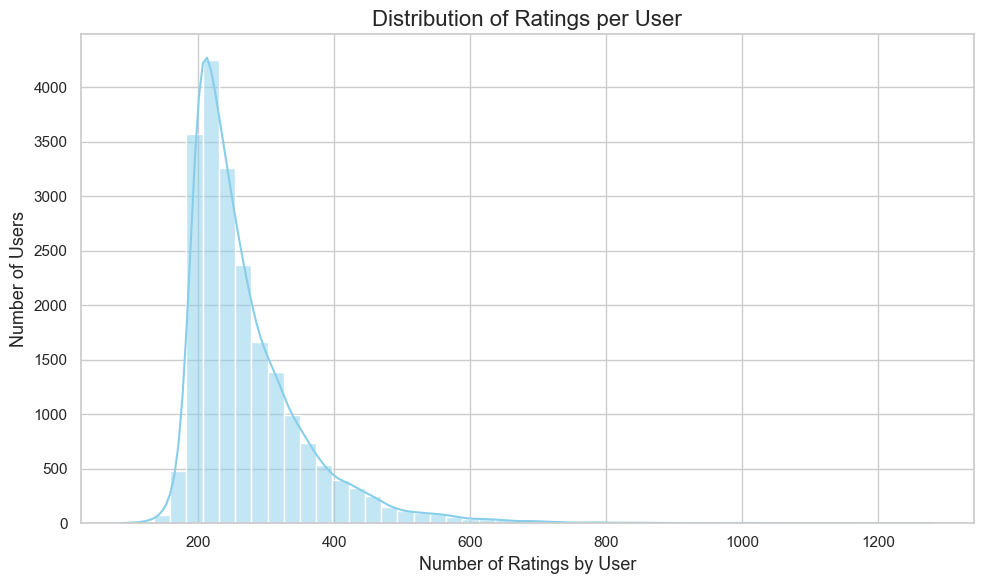

In [7]:
# Plot user activity distribution
sns.histplot(user_ratings_count, bins=50, kde=True, color="skyblue")
plt.title("Distribution of Ratings per User")
plt.xlabel("Number of Ratings by User")
plt.ylabel("Number of Users")
plt.tight_layout()
plt.savefig("user_activity_distribution.png", dpi=300)
plt.show()

### 5. Content Popularity Trends

In [8]:
# Find the top 10 most rated movies
movie_popularity = df_ratings.groupby("movie_id")["rating"].agg(["count", "mean"])
movie_popularity = movie_popularity.merge(df_movies, on="movie_id")

print("Top 10 Most Rated Movies:")
print(movie_popularity.sort_values(by="count", ascending=False)[["movie_id", "title", "year", "count", "mean"]].head(10).to_string(index=False))

Top 10 Most Rated Movies:
 movie_id                                                  title  year  count     mean
     1905 Pirates of the Caribbean: The Curse of the Black Pearl  2003  19919 4.164165
     4306                                        The Sixth Sense  1999  19841 4.331838
     2862                               The Silence of the Lambs  1991  19442 4.324195
     2452          Lord of the Rings: The Fellowship of the Ring  2001  19101 4.426156
      607                                                  Speed  1994  18683 3.565594
     2782                                             Braveheart  1995  18598 4.257662
      571                                        American Beauty  1999  18592 3.911360
     3106                                                  Ghost  1990  18361 3.567507
      798                                                   Jaws  1975  18186 3.921093
     3860                                         Bruce Almighty  2003  17986 3.369454


In [9]:
# Find the top 10 highest rated movies
print("Top 10 Highest Rated Movies (in subset):")
print(movie_popularity.sort_values(by="mean", ascending=False)[["movie_id", "title", "year", "count", "mean"]].head(10).to_string(index=False))

Top 10 Highest Rated Movies (in subset):
 movie_id                                         title  year  count     mean
     3456                                Lost: Season 1  2004   1345 4.656506
     2102                        The Simpsons: Season 6  1994   2854 4.509460
     3444         Family Guy: Freakin' Sweet Collection  2004   2890 4.434948
     2452 Lord of the Rings: The Fellowship of the Ring  2001  19101 4.426156
     2172                        The Simpsons: Season 3  1991   6353 4.385802
     1256                   The Best of Friends: Vol. 4  1994   3001 4.371876
     3962                     Finding Nemo (Widescreen)  2003  17984 4.368494
     3046             The Simpsons: Treehouse of Horror  1990   5147 4.347970
     1476                      Six Feet Under: Season 4  2004   2642 4.344436
     4306                               The Sixth Sense  1999  19841 4.331838


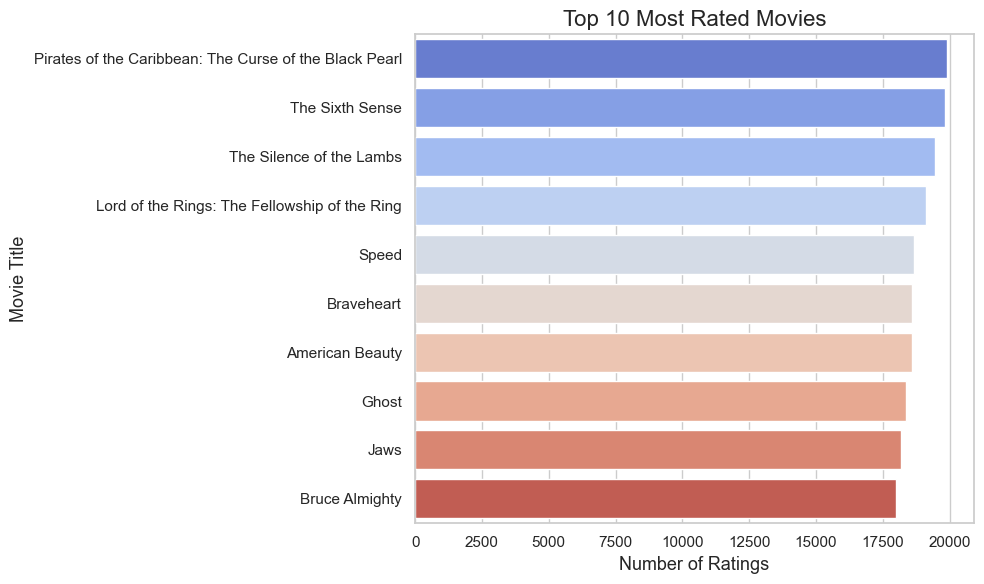

In [10]:
# Plot top 10 most active/rated movies
top_10_most_rated = movie_popularity.sort_values(by="count", ascending=False).head(10)
sns.barplot(x="count", y="title", data=top_10_most_rated, hue="title", palette="coolwarm", legend=False)
plt.title("Top 10 Most Rated Movies")
plt.xlabel("Number of Ratings")
plt.ylabel("Movie Title")
plt.tight_layout()
plt.savefig("top_movies_popularity.png", dpi=300)
plt.show()

### 6. Key Observations and Insights

1. **Matrix Sparsity**: Our dense subset has a density of around 21% (meaning 21% of all user-movie combinations are present). While this is dense compared to the raw dataset (which has <1% density), it is still 79% sparse. This represents a classic collaborative filtering challenge, and proves why dimensionality reduction models like SVD are essential.

2. **Rating Bias**: Ratings are highly skewed towards positive scores: ratings of `4` and `5` make up a massive percentage of total reviews, and the mean rating is well above `3.5`. This positive rating bias is typical of user self-selection (users tend to watch and rate movies they expect to enjoy).

3. **Long Tail vs. Blockbusters**: A small fraction of blockbusters (like *Lord of the Rings* or *Gladiator*) capture a disproportionate share of ratings. This heavy-tailed distribution confirms that recommendation quality should balance predicting scores on the long-tail vs. highlighting popular hits.